In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
import scipy.optimize as sopt
from tqdm import tqdm

In [2]:
def fit_g(y, Nkpoints, expons, weight_fac=0):
    y_pred = np.zeros((expons.shape[0], Nkpoints.shape[0]))
    yinf_pred = np.zeros(expons.shape[0])
    losses = np.zeros(expons.shape[0])
    for expInd in range(expons.shape[0]):
        exp = expons[expInd]
        x = Nkpoints**(-exp)
        x2 = x * x
        
        wt = Nkpoints**(weight_fac*exp)
        p = wt / np.sum(wt)
        
        xavg, x2avg = np.sum(p*x), np.sum(p*x2)
        yavg, xyavg = np.sum(p*y), np.sum(p*x*y)
        
        alpha = (xyavg - xavg*yavg)/(x2avg - xavg**2)
        beta = yavg - alpha * xavg
        
        yinf_pred[expInd] = beta
        y_pred[expInd, :] = alpha * x + beta

        losses[expInd] = np.linalg.norm(y - y_pred[expInd, :])**2 / (y.shape[0])
    
    return y_pred, yinf_pred, losses

In [3]:
# save the data so that we don't have it all the time
import pickle
with open("GF_data.pkl", "rb") as fl:
    GF_data = pickle.load(fl)
    
with open("Pmax_GF_Data.pkl", "rb") as fl:
    Pmax_GF_Data = pickle.load(fl)

In [4]:
# Let's first check the pmax values
print('pmaxerror\tG0inf')
for pmax in sorted(Pmax_GF_Data.keys(), reverse=True):
    
    # get the GF data for the pmax value 
    data = Pmax_GF_Data[pmax]
    
    Nkpt = np.array([N for (N,Nr, g0, gR) in data])
    y_0 = np.array([g0 for (N,Nr, g0, gR) in data])
    
    # vary the fit exponents between a range
    # g = (alpha * Nkpt^(-exponent) + Ginf)
    exponents = np.arange(1.5, 5, 0.01)
    
    # Get the weighted least squares extrapolations
    # weight = Nkpt^(weight_fac * exponent) for each exponent and Nkpt value.
    g0_pred, g0_inf, loss_g0 = fit_g(y_0, Nkpt, exponents, weight_fac=1)
    
    # See which exponent gives minimum loss
    # and get the g0inf for that
    mn0 = np.argmin(loss_g0)
    G0inf = g0_inf[mn0]
    
    print('{}\t \t{}'.format(pmax, G0inf))

pmaxerror	G0inf
-6	 	-0.15125712409502823
-7	 	-0.15125712093829882
-8	 	-0.15125712069635852
-9	 	-0.15125712076269401
-10	 	-0.1512571208286163


In [5]:
# pmax with threshold of 1e-8 is sufficiently accurate upto 1e-10 as far as G0inf is concerned.
g0 = np.array([g0 for (Nkpt, Nreduce, g0, gR) in GF_data])
gR = np.array([gR for (Nkpt, Nreduce, g0, gR) in GF_data])
Nkpt = np.array([Nkpt for (Nkpt, Nreduce, g0, gR) in GF_data])

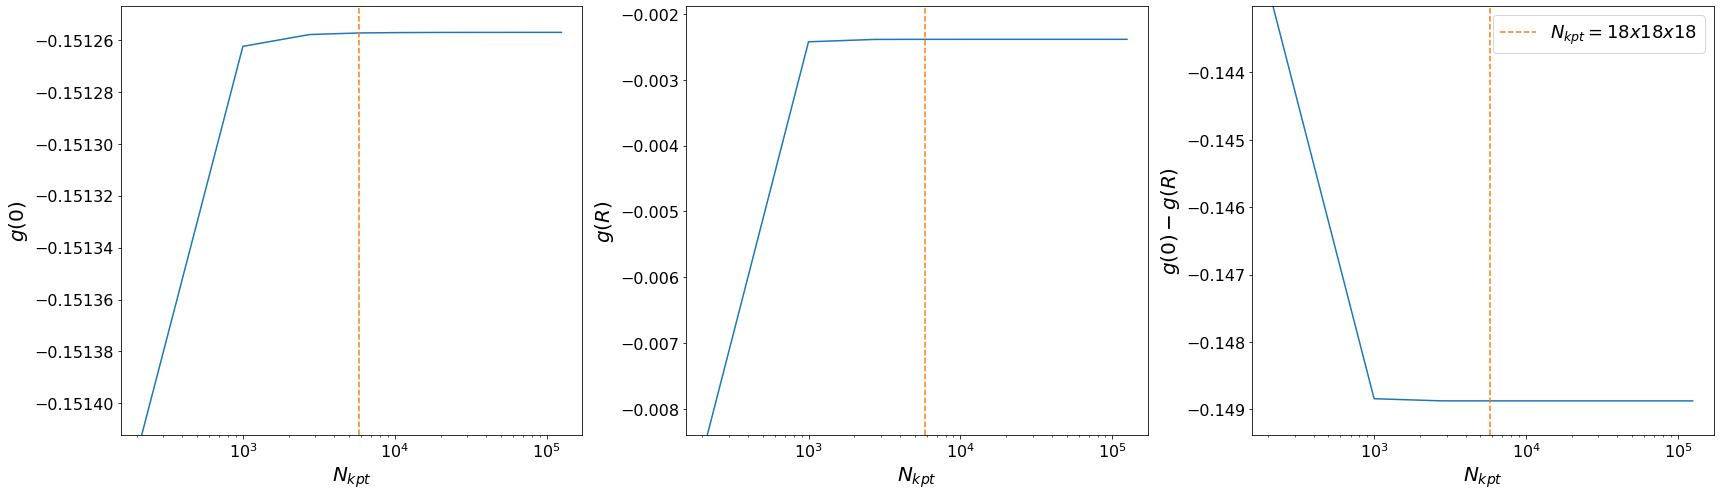

In [6]:
plt.figure(figsize=(24,7))
plt.subplot(1, 3, 1)
plt.semilogx(Nkpt, g0)
plt.axvline(x=18*18*18, color="tab:orange", label=r'$N_{kpt} = 18x18x18$', ls="--")
plt.xlabel(r'$N_{kpt}$', fontsize=20)
plt.ylabel(r'$g(0)$', fontsize=20)
plt.ylim(np.min(g0),np.max(g0) + 1e-5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.subplot(1, 3, 2)
plt.semilogx(Nkpt, gR)
plt.axvline(x=18*18*18, color="tab:orange", label=r'$N_{kpt} = 18x18x18$', ls="--")
plt.xlabel(r'$N_{kpt}$', fontsize=20)
plt.ylabel(r'$g(R)$', fontsize=20)
plt.ylim(np.min(gR),np.max(gR) + 5e-4)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.subplot(1, 3, 3)
plt.semilogx(Nkpt, g0 - gR)
plt.axvline(x=18*18*18, color="tab:orange", ls="--", label=r'$N_{kpt} = 18x18x18$')
plt.xlabel(r'$N_{kpt}$', fontsize=20)
plt.ylabel(r'$g(0) - g(R)$', fontsize=20)
plt.ylim(np.min(g0-gR) - 5e-4,np.max(g0-gR))
plt.legend(fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

In [7]:
Nkpt = np.array([N for (N,Nr, g0, gR) in GF_data])
Nkpt

array([   216,   1000,   2744,   5832,  10648,  17576,  27000,  39304,
        54872,  74088,  97336, 125000])

In [8]:
g_wt = {}

wt = 1

Nkpt = np.array([N for (N,Nr, g0, gR) in GF_data])

exponents = np.arange(1.5, 5, 0.01)
y_0 = np.array([g0 for (N,Nr, g0, gR) in GF_data])
y_R = np.array([gR for (N,Nr, g0, gR) in GF_data])

Nfit = y_0.shape[0]# 6 # maximum number of points to send in

g0_pred, g0_inf, loss_g0 = fit_g(y_0[:Nfit], Nkpt[:Nfit], exponents, weight_fac=wt)
gR_pred, gR_inf, loss_gR = fit_g(y_R[:Nfit], Nkpt[:Nfit], exponents, weight_fac=wt)
gR0_pred, gR0_inf, loss_gR0 = fit_g(y_R[:Nfit] - y_0[:Nfit], Nkpt[:Nfit], exponents, weight_fac=wt)

In [9]:
mn0 = np.argmin(loss_g0)
mnR = np.argmin(loss_gR)
mnR0 = np.argmin(loss_gR0)

Emin_0 = exponents[mn0]
Emin_R = exponents[mnR]
Emin_R0 = exponents[mnR0]
Emin_0, Emin_R, Emin_R0

(2.1600000000000006, 3.3100000000000014, 3.4000000000000017)

In [10]:
G0inf = g0_inf[mn0]
g0_err = np.array([np.abs(G0inf - g0) for (N, Nr, g0, gR) in GF_data])

GRinf = gR_inf[mnR]
gR_err = np.array([np.abs(GRinf - gR) for (N, Nr, g0, gR) in GF_data])

GR0inf = gR0_inf[mnR0]
gR0_err = np.array([np.abs(GR0inf - gR + g0) for (N, Nr, g0, gR) in GF_data])

In [11]:
G0inf - g0[3], GRinf - gR[3], GR0inf - (y_R[3] - y_0[3])

(2.2968395629874294e-07, 2.751556796029911e-07, 4.497711897366585e-08)

In [12]:
G0inf - g0[3], GRinf - gR[3], GR0inf - (y_R[3] - y_0[3])

(2.2968395629874294e-07, 2.751556796029911e-07, 4.497711897366585e-08)

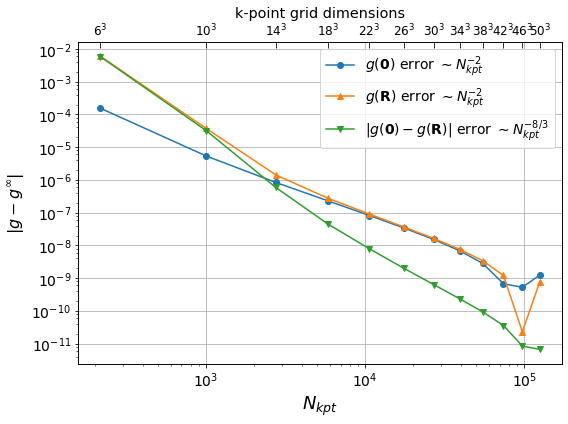

In [13]:
# plt.figure(figsize=(6, 6))
fig, ax=plt.subplots(figsize=(8, 6))
ax.loglog(Nkpt, g0_err, marker="o", label=r'$g(\mathbf{0})$ error $\sim N_{kpt}^{-2}$')
ax.loglog(Nkpt, gR_err, marker="^", label=r'$g(\mathbf{R})$ error $\sim N_{kpt}^{-2}$')
ax.loglog(Nkpt, gR0_err, marker="v", label=r'$|g(\mathbf{0}) - g(\mathbf{R})|$ error $\sim N_{kpt}^{-8/3}$')
ax.set_xlabel(r'$N_{kpt}$', fontsize=18)
ax.set_ylabel(r'$|g - g^{\infty}|$', fontsize=16)

locmaj = matplotlib.ticker.LogLocator(base=10,numticks=12) 
ax.yaxis.set_major_locator(locmaj)
locmin = matplotlib.ticker.LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=12)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

# plt.axvline(x=18*18*18, label=r'$N_{kpt} = 18^3$', ls="--")
# plt.axhline(y=np.abs(GR0inf - (y_R[3] - y_0[3])), label=r"$E = {:.1e}$".format(np.abs(GR0inf - (y_R[3] - y_0[3]))),
#             ls=":", color="k")

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True)
ax.legend(fontsize=14)


ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([n for n in Nkpt])
ax2.set_xticklabels(["${:.0f}^3$".format(N**(1/3)) for N in Nkpt])
ax2.set_xlabel('k-point grid dimensions', fontsize='x-large')

ax2.tick_params(axis='x', top='on', direction='in', length=6, labelsize=12)
ax2.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())

ax2.grid(False)

plt.tight_layout()
# plt.savefig("Error_Scale.eps", format="eps")

In [14]:
(np.log(g0_err[8]) - np.log(g0_err[3]))/(np.log(Nkpt[8]) - np.log(Nkpt[3]))

-1.9644116660169015

In [15]:
(np.log(gR_err[8]) - np.log(gR_err[3]))/(np.log(Nkpt[8]) - np.log(Nkpt[3]))

-1.9602462725391867

In [16]:
(np.log(gR0_err[8]) - np.log(gR_err[3]))/(np.log(Nkpt[8]) - np.log(Nkpt[3]))

-3.5640668129536506

In [18]:
from scipy import stats
stats.linregress(np.log(Nkpt[3:9]), np.log(g0_err[3:9]))

LinregressResult(slope=-1.9297077027275875, intercept=1.5579887641764572, rvalue=-0.9970182881015607, pvalue=1.3322654155325303e-05, stderr=0.07467621035188389, intercept_stderr=0.7416632450015685)

In [19]:
stats.linregress(np.log(Nkpt[3:9]), np.log(gR_err[3:9]))

LinregressResult(slope=-1.9327174008937078, intercept=1.706338132048014, rvalue=-0.9989639065133686, pvalue=1.609678451710075e-06, stderr=0.04402410261399943, intercept_stderr=0.4372350799421244)

In [20]:
stats.linregress(np.log(Nkpt[3:9]), np.log(gR0_err[3:9]))

LinregressResult(slope=-2.740546853774958, intercept=6.792690998622746, rvalue=-0.9998517869475111, pvalue=3.2949035485986464e-08, stderr=0.023594660879233856, intercept_stderr=0.2343355758138399)

In [21]:
8/3

2.6666666666666665